# MIMIC-IV — Exploratory Data Analysis

Profiles the MIMIC-IV `hosp` module for both Preventra phases in one pass:

- **Part 1 — Discharge-time data.** Cohort size, 30-day readmission rate, feature availability,
  and which subgroups actually differ in outcome.
- **Part 2 — Post-discharge data.** What `omr` contains, how much of it lands after discharge,
  and whether a weekly monitoring cadence exists at all.

### A note on how this reads the data

`labevents.csv` is **18.4 GB** and `prescriptions.csv` is **3.5 GB**; a Kaggle CPU session has
**32 GB RAM** and pandas needs roughly 3-5x a CSV's disk size once parsed. Both are therefore
**streamed in chunks** and reduced to per-admission aggregates. Everything else is small enough
to load directly. Nothing large is ever held whole.

Results are cached to `/kaggle/working`, so a second run skips the expensive scans.

## 0 · Setup

In [1]:
import os, gc, re, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

CHUNK_ROWS    = 2_000_000
COMPACT_EVERY = 8
CACHE_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./cache"
os.makedirs(CACHE_DIR, exist_ok=True)

NAVY, RED, AMBER, GREEN = "#0F2A4A", "#C0392B", "#F0A500", "#1E7D44"

def report(label, df):
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  {label:<32} rows={len(df):>12,}  cols={df.shape[1]:>3}  mem={mem:>8.1f} MB")

def pct(n, d):
    return f"{100.0*n/d:.1f}%" if d else "n/a"

def cache_path(name):
    return os.path.join(CACHE_DIR, f"eda_{name}.parquet")

def load_cache(name):
    p = cache_path(name)
    if os.path.exists(p):
        print(f"  [cache hit] {name}")
        return pd.read_parquet(p)
    return None

def save_cache(df, name):
    df.to_parquet(cache_path(name), index=False)
    print(f"  [cached] {name}")

def barh(series, title, xlabel, color=NAVY, top=None, fmt="{:.0f}"):
    """Horizontal bar chart with value labels — used throughout for readability."""
    s = series if top is None else series.head(top)
    s = s.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(2.2, .38*len(s))))
    ax.barh([str(i) for i in s.index], s.values, color=color)
    for y, v in enumerate(s.values):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=9)
    ax.set(title=title, xlabel=xlabel)
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()

In [2]:
def find_mimic_root():
    bases = ["/kaggle/input", "./data", ".", "..","/kaggle/input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp"]
    hits = []
    for base in bases:
        if not os.path.isdir(base):
            continue
        for depth in range(4):
            for stem in ("admissions.csv*", "sample_admissions.csv*"):
                hits += [os.path.dirname(p)
                         for p in glob.glob(os.path.join(base, *(["*"]*depth), stem))]
    for h in sorted(set(hits), key=len):
        if (glob.glob(os.path.join(h, "diagnoses_icd.csv*"))
                or glob.glob(os.path.join(h, "sample_diagnoses_icd.csv*"))):
            return h
    return hits[0] if hits else None

MIMIC = find_mimic_root()
if MIMIC is None:
    raise FileNotFoundError("admissions.csv not found. On Kaggle, attach the MIMIC-IV dataset.")
print("MIMIC-IV hosp directory:", MIMIC)

def tbl(name):
    for cand in (f"{name}.csv", f"{name}.csv.gz", f"sample_{name}.csv"):
        p = os.path.join(MIMIC, cand)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(name)

def has(name):
    try:
        tbl(name); return True
    except FileNotFoundError:
        return False

TABLES = ["admissions","patients","diagnoses_icd","procedures_icd","drgcodes","omr",
          "prescriptions","labevents","d_labitems","d_icd_diagnoses","transfers","services"]

rows = []
for t in TABLES:
    if not has(t):
        rows.append({"table": t, "GB": None, "columns": "not present"}); continue
    p = tbl(t)
    cols = pd.read_csv(p, nrows=0).columns.tolist()
    rows.append({"table": t, "GB": round(os.path.getsize(p)/1024**3, 3),
                 "n_cols": len(cols), "columns": ", ".join(cols[:7]) + ("..." if len(cols) > 7 else "")})
inv = pd.DataFrame(rows)
print("\nTABLE INVENTORY")
print(inv.to_string(index=False))
big = inv[inv.GB.fillna(0) > .5].table.tolist()
print(f"\nstreamed (>0.5 GB): {big or 'none'}")

MIMIC-IV hosp directory: /kaggle/input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp

TABLE INVENTORY
          table     GB  n_cols                                                                                    columns
     admissions  0.088      16 subject_id, hadm_id, admittime, dischtime, deathtime, admission_type, admit_provider_id...
       patients  0.011       6                        subject_id, gender, anchor_age, anchor_year, anchor_year_group, dod
  diagnoses_icd  0.169       5                                        subject_id, hadm_id, seq_num, icd_code, icd_version
 procedures_icd  0.032       6                             subject_id, hadm_id, seq_num, chartdate, icd_code, icd_version
       drgcodes  0.051       7          subject_id, hadm_id, drg_type, drg_code, description, drg_severity, drg_mortality
            omr  0.299       5                                  subject_id, chartdate, seq_num, result_name, result_value
  prescriptions  3.249      21       

---
# Part 1 · Discharge-time data

## 1.1 Cohort construction

Exclusions follow standard readmission-measure practice. The **order matters**: the next
admission is identified on the full sequence *before* any rows are dropped, otherwise a
readmission that happened to follow an excluded stay would be lost.

  admissions                       rows=     546,028  cols= 13  mem=   211.5 MB
  patients                         rows=     364,627  cols=  5  mem=    28.5 MB

admissions columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
patients columns  : ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'dod']

EXCLUSION WATERFALL
all admissions                 546028
- died in hospital             -11801
- hospice/died at discharge    -17118
- observation stays           -235639
= eligible index stays         296760


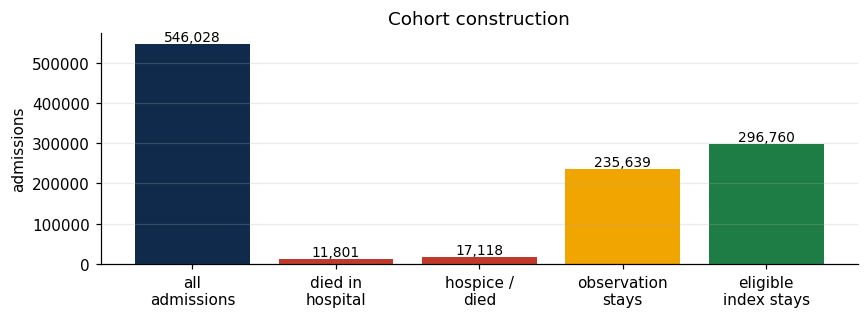

In [3]:
TERMINAL = {"DIED", "HOSPICE"}
OBSERVATION = {"EU OBSERVATION","OBSERVATION ADMIT","AMBULATORY OBSERVATION","DIRECT OBSERVATION"}
WINDOW = 30

adm = pd.read_csv(tbl("admissions"),
    usecols=["subject_id","hadm_id","admittime","dischtime","admission_type","admission_location",
             "discharge_location","insurance","marital_status","race","edregtime","edouttime",
             "hospital_expire_flag"],
    parse_dates=["admittime","dischtime","edregtime","edouttime"])
patients = pd.read_csv(tbl("patients"),
    usecols=["subject_id","gender","anchor_age","anchor_year","dod"], parse_dates=["dod"])
report("admissions", adm); report("patients", patients)

print("\nadmissions columns:", list(adm.columns))
print("patients columns  :", list(patients.columns))

adm = adm.sort_values(["subject_id","admittime"]).reset_index(drop=True)
adm["n_prior_adm"]   = adm.groupby("subject_id").cumcount()
adm["prev_disch"]    = adm.groupby("subject_id")["dischtime"].shift(1)
adm["days_since_prev"] = (adm.admittime - adm.prev_disch).dt.total_seconds()/86400
adm["next_admit"]    = adm.groupby("subject_id")["admittime"].shift(-1)
adm["next_type"]     = adm.groupby("subject_id")["admission_type"].shift(-1)
adm["days_to_next"]  = (adm.next_admit - adm.dischtime).dt.total_seconds()/86400

died  = adm.hospital_expire_flag.eq(1)
term  = adm.discharge_location.isin(TERMINAL)
obs   = adm.admission_type.isin(OBSERVATION)
coh = adm[~(died | term | obs)].copy()
coh["readmit_30d"] = (coh.days_to_next.between(0, WINDOW) & ~coh.next_type.eq("ELECTIVE")).astype("int8")
coh["los_days"] = (coh.dischtime - coh.admittime).dt.total_seconds()/86400

steps = pd.Series({
    "all admissions": len(adm),
    "- died in hospital": -int(died.sum()),
    "- hospice/died at discharge": -int(term.sum()),
    "- observation stays": -int(obs.sum()),
    "= eligible index stays": len(coh),
})
print("\nEXCLUSION WATERFALL"); print(steps.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
labels = ["all\nadmissions","died in\nhospital","hospice /\ndied","observation\nstays","eligible\nindex stays"]
vals   = [len(adm), int(died.sum()), int(term.sum()), int(obs.sum()), len(coh)]
ax.bar(labels, vals, color=[NAVY, RED, RED, AMBER, GREEN])
for i,v in enumerate(vals): ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set(title="Cohort construction", ylabel="admissions"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 1.2 Headline numbers

  eligible index stays      : 296,760
  distinct patients         : 148,669
  admissions per patient    : 2.00
  30-day unplanned readmits : 58,345
  POSITIVE RATE             : 19.66%
  all-cause (incl elective) : 20.63%

admissions per patient:
1    90893
2    29258
3    11893
4     5963
5     3222
6     2049
7     1419
8      926

patients with >1 admission: 38.9%  <- drives any longitudinal view


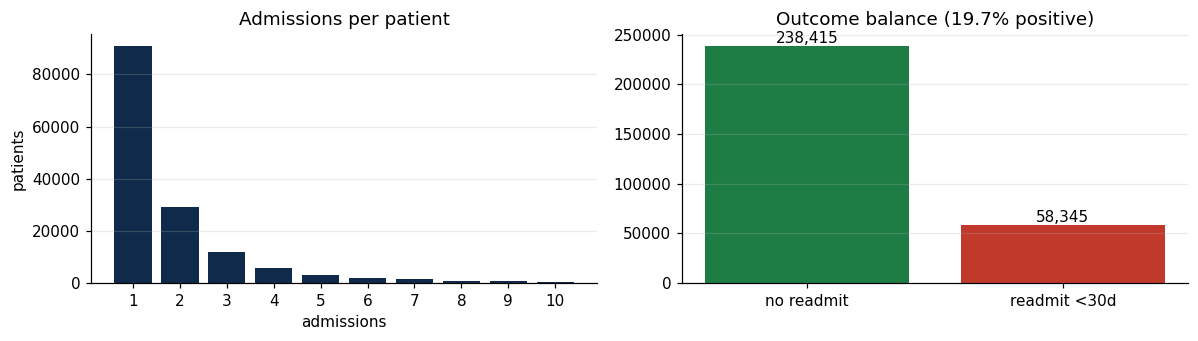

In [4]:
n_adm, n_pat = len(coh), coh.subject_id.nunique()
pos = int(coh.readmit_30d.sum())
print(f"  eligible index stays      : {n_adm:,}")
print(f"  distinct patients         : {n_pat:,}")
print(f"  admissions per patient    : {n_adm/max(n_pat,1):.2f}")
print(f"  30-day unplanned readmits : {pos:,}")
print(f"  POSITIVE RATE             : {pos/max(n_adm,1):.2%}")
print(f"  all-cause (incl elective) : {coh.days_to_next.between(0,WINDOW).mean():.2%}")

per_pat = coh.groupby("subject_id").size().value_counts().sort_index()
print("\nadmissions per patient:")
print(per_pat.head(8).to_string())
multi = (coh.groupby('subject_id').size() > 1).mean()
print(f"\npatients with >1 admission: {multi:.1%}  <- drives any longitudinal view")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
h = per_pat.head(10)
ax[0].bar(h.index.astype(str), h.values, color=NAVY)
ax[0].set(title="Admissions per patient", xlabel="admissions", ylabel="patients")
ax[0].grid(axis="x", visible=False)
ax[1].bar(["no readmit","readmit <30d"], [n_adm-pos, pos], color=[GREEN, RED])
for i,v in enumerate([n_adm-pos, pos]): ax[1].text(i, v, f"{v:,}", ha="center", va="bottom")
ax[1].set(title=f"Outcome balance ({pos/max(n_adm,1):.1%} positive)")
ax[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 1.3 Who is in the cohort

age      : {'mean': 57.6, '50%': 59.0, 'min': 18.0, 'max': 91.0}
LOS days : {'mean': 5.84, '50%': 3.84, 'max': 321.58}


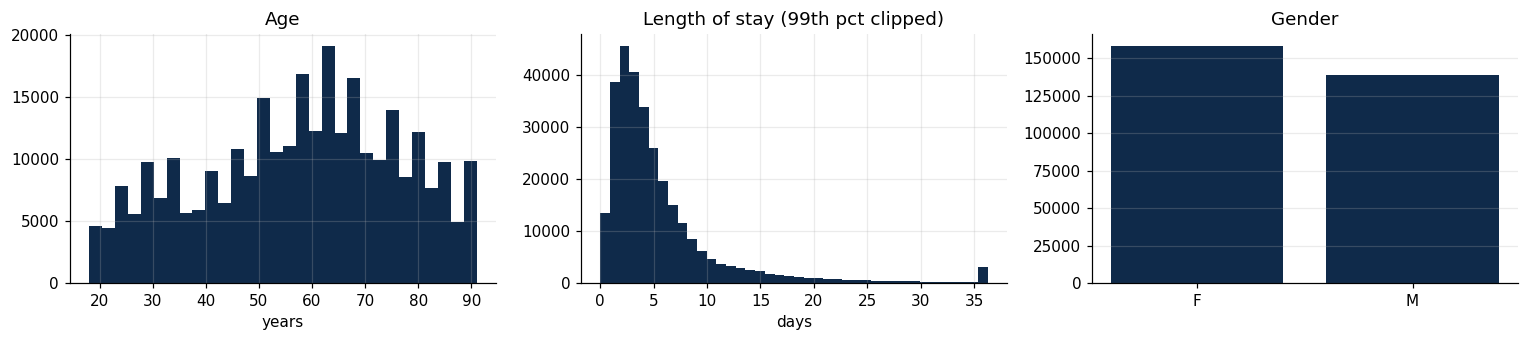

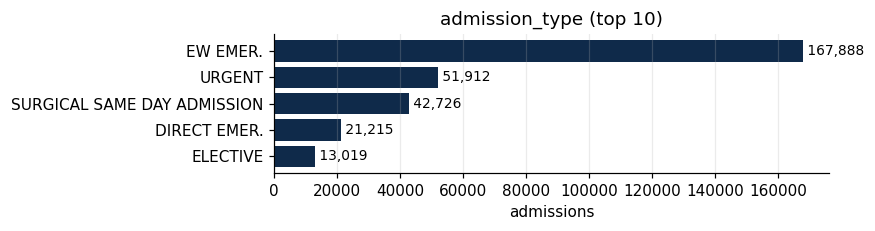

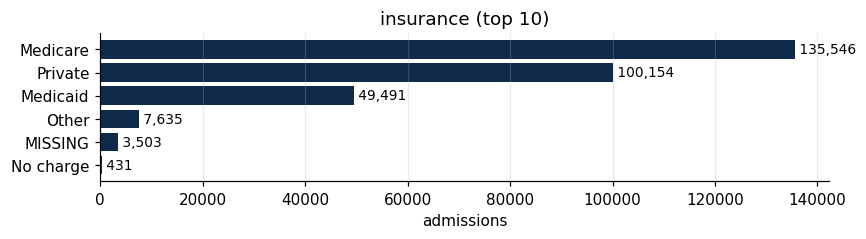

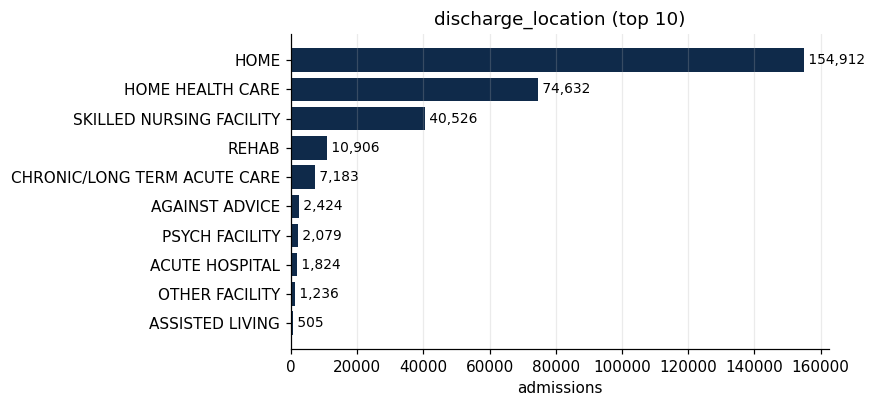

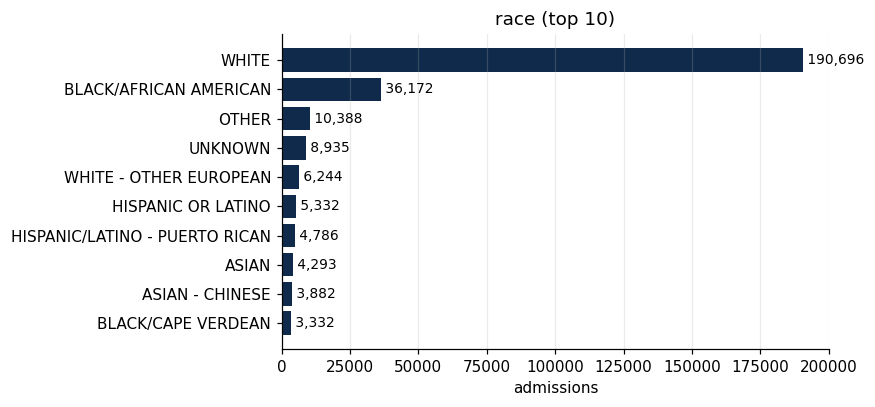

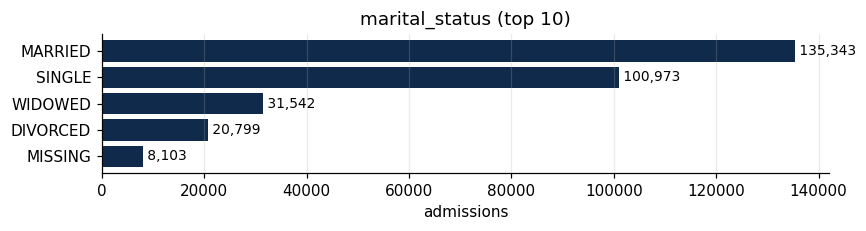

In [5]:
coh = coh.merge(patients[["subject_id","gender","anchor_age"]], on="subject_id", how="left")

print("age      :", coh.anchor_age.describe()[["mean","50%","min","max"]].round(1).to_dict())
print("LOS days :", coh.los_days.describe()[["mean","50%","max"]].round(2).to_dict())

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
ax[0].hist(coh.anchor_age.dropna(), bins=30, color=NAVY)
ax[0].set(title="Age", xlabel="years")
los = coh.los_days.clip(0, coh.los_days.quantile(.99))
ax[1].hist(los.dropna(), bins=40, color=NAVY)
ax[1].set(title="Length of stay (99th pct clipped)", xlabel="days")
g = coh.gender.value_counts()
ax[2].bar(g.index.astype(str), g.values, color=NAVY); ax[2].set(title="Gender")
ax[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

for col in ["admission_type","insurance","discharge_location","race","marital_status"]:
    vc = coh[col].fillna("MISSING").value_counts()
    barh(vc, f"{col} (top 10)", "admissions", top=10, fmt="{:,.0f}")

## 1.4 Which subgroups actually differ

Counts describe the cohort; **rates** tell you whether a feature carries signal. Groups with
fewer than 100 admissions are dropped, because a rate over a handful of stays is noise.


=== 30-day readmission rate by discharge_location ===
                                   n  rate
_g                                        
PSYCH FACILITY                  2079  51.6
AGAINST ADVICE                  2424  34.3
MISSING                          501  29.5
ACUTE HOSPITAL                  1824  29.4
CHRONIC/LONG TERM ACUTE CARE    7183  27.9
HOME HEALTH CARE               74632  24.0
SKILLED NURSING FACILITY       40526  21.8
ASSISTED LIVING                  505  20.2
OTHER FACILITY                  1236  19.9
REHAB                          10906  18.3
HOME                          154912  15.9


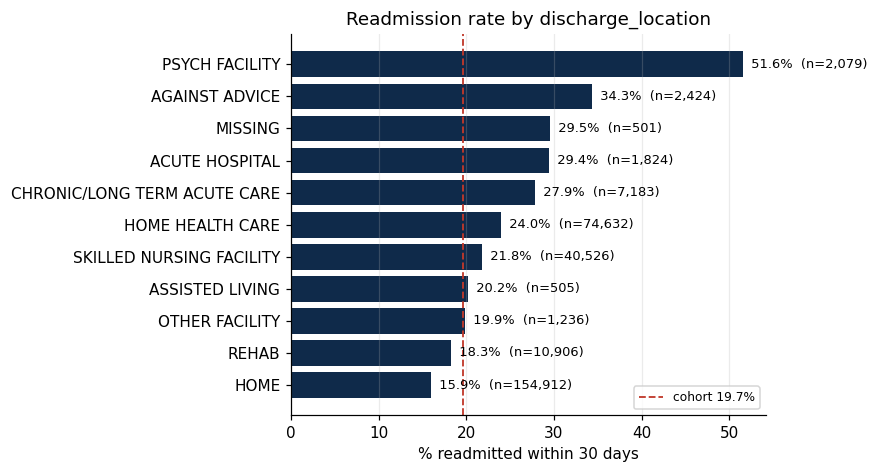


=== 30-day readmission rate by insurance ===
                n  rate
_g                     
Medicare   135546  21.7
Medicaid    49491  21.1
Other        7635  17.0
Private    100154  16.6
MISSING      3503  13.2
No charge     431   9.0


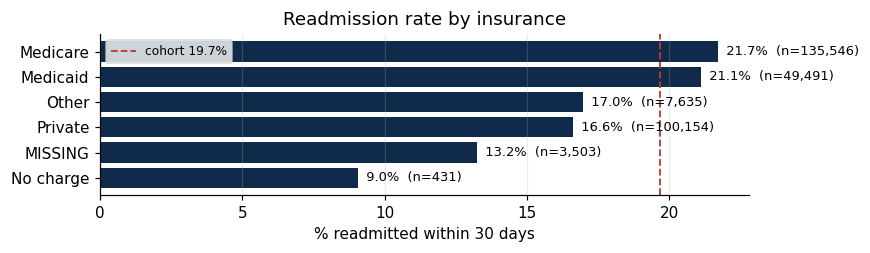


=== 30-day readmission rate by admission_type ===
                                  n  rate
_g                                       
DIRECT EMER.                  21215  30.6
EW EMER.                     167888  21.0
ELECTIVE                      13019  19.6
URGENT                        51912  15.1
SURGICAL SAME DAY ADMISSION   42726  14.4


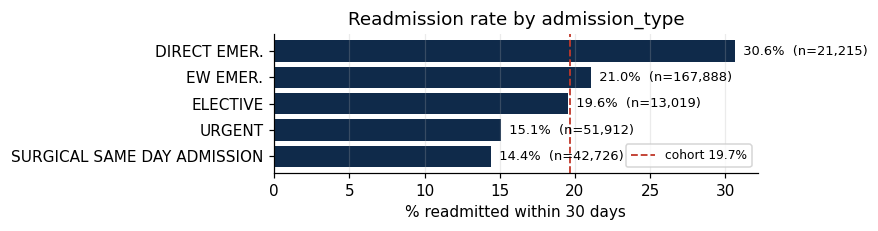


=== 30-day readmission rate by age band ===
           n  rate
_g                
55-64  59967  21.5
40-54  62858  21.4
65-74  52636  20.7
75-84  39610  20.0
85+    17854  18.7
<40    63835  15.4


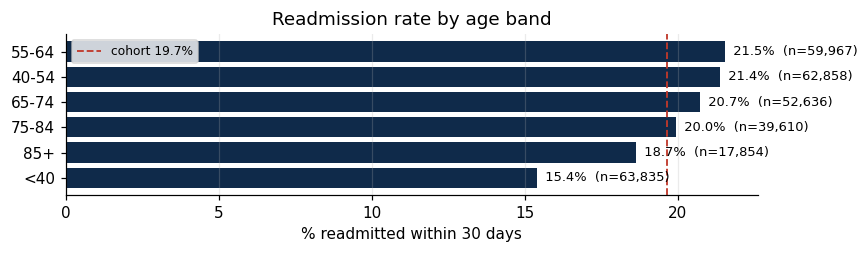


=== 30-day readmission rate by length of stay ===
            n  rate
_g                 
14d+    21301  28.5
7-14d   45949  24.8
3-7d   114599  19.7
<1d     17703  16.2
1-3d    97199  15.9


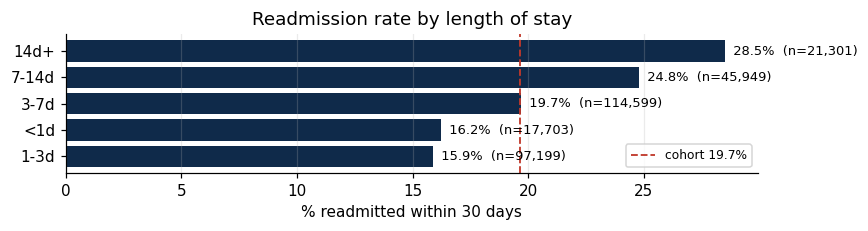


=== 30-day readmission rate by prior admissions ===
          n  rate
_g               
6+    39785  36.5
3-5   41383  25.3
2     30728  20.6
1     58919  16.6
0    125945  13.7


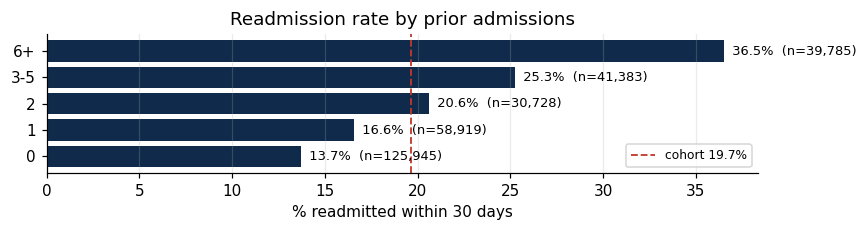

,n,rate
_g,,
6+,39785,0.365138
3-5,41383,0.252737
2,30728,0.205903
1,58919,0.165668
0,125945,0.137131


In [6]:
MIN_N = 100

def rate_by(col, series=None, title=None, top=12):
    s = series if series is not None else coh[col].fillna("MISSING")
    g = coh.assign(_g=s).groupby("_g").agg(n=("readmit_30d","size"), rate=("readmit_30d","mean"))
    g = g[g.n >= MIN_N].sort_values("rate", ascending=False)
    if g.empty:
        print(f"  {col}: no group reaches n>={MIN_N}"); return None
    print(f"\n=== 30-day readmission rate by {title or col} ===")
    print(g.assign(rate=(g.rate*100).round(1)).head(top).to_string())
    gg = g.head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(2.2, .4*len(gg))))
    ax.barh([str(i) for i in gg.index], gg.rate*100, color=NAVY)
    ax.axvline(coh.readmit_30d.mean()*100, color=RED, ls="--", lw=1.2,
               label=f"cohort {coh.readmit_30d.mean()*100:.1f}%")
    for y,(v,n) in enumerate(zip(gg.rate*100, gg.n)):
        ax.text(v, y, f"  {v:.1f}%  (n={n:,})", va="center", fontsize=8.5)
    ax.set(title=f"Readmission rate by {title or col}", xlabel="% readmitted within 30 days")
    ax.grid(axis="y", visible=False); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return g

rate_by("discharge_location")
rate_by("insurance")
rate_by("admission_type")
rate_by("age_band", pd.cut(coh.anchor_age, [0,40,55,65,75,85,120],
                           labels=["<40","40-54","55-64","65-74","75-84","85+"]), "age band")
rate_by("los_band", pd.cut(coh.los_days, [-.01,1,3,7,14,10000],
                           labels=["<1d","1-3d","3-7d","7-14d","14d+"]), "length of stay")
rate_by("prior_adm", pd.cut(coh.n_prior_adm, [-.01,0,1,2,5,10000],
                            labels=["0","1","2","3-5","6+"]), "prior admissions")

## 1.5 Comorbidity — and the ICD version split

  diagnoses (cohort)               rows=   3,628,115  cols=  3  mem=   268.4 MB

ICD version split: ICD-9 61.8% / ICD-10 38.2%
  !! BOTH versions present in volume. Any comorbidity mapping must cover both,
     or roughly half the cohort silently scores zero.

diagnoses per admission: median 11, mean 12.2, max 57

most common diagnoses:
icd_code  icd_version     n                                                      label
    4019            9 73750                         Unspecified essential hypertension
    2724            9 52108                       Other and unspecified hyperlipidemia
   53081            9 37505                                          Esophageal reflux
    E785           10 34077                                Hyperlipidemia, unspecified
     I10           10 31959                           Essential (primary) hypertension
   25000            9 30475 Diabetes mellitus without mention of complication, type II
    4280            9 30278                      Con

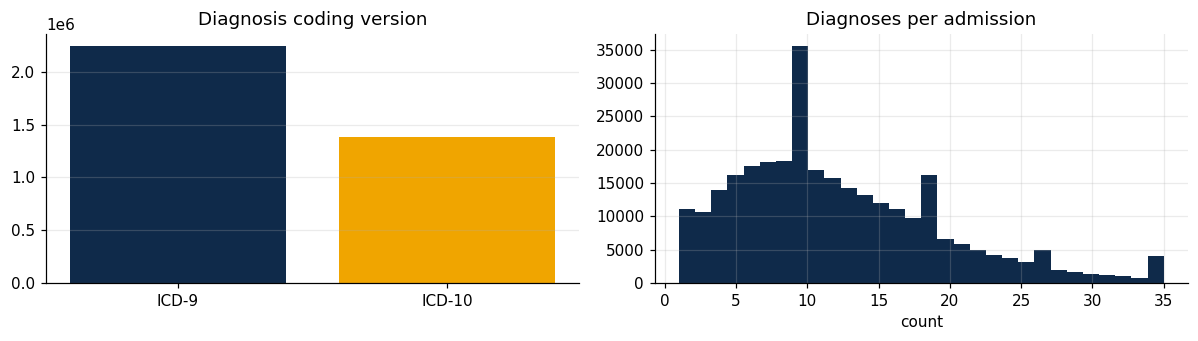

48821

In [7]:
dx = pd.read_csv(tbl("diagnoses_icd"), usecols=["hadm_id","icd_code","icd_version"])
dx = dx[dx.hadm_id.isin(set(coh.hadm_id))]
report("diagnoses (cohort)", dx)

split = dx.icd_version.value_counts(normalize=True)
print(f"\nICD version split: ICD-9 {split.get(9,0):.1%} / ICD-10 {split.get(10,0):.1%}")
if split.get(10, 0) > .05 and split.get(9, 0) > .05:
    print("  !! BOTH versions present in volume. Any comorbidity mapping must cover both,")
    print("     or roughly half the cohort silently scores zero.")

n_dx = dx.groupby("hadm_id").size()
print(f"\ndiagnoses per admission: median {n_dx.median():.0f}, mean {n_dx.mean():.1f}, max {n_dx.max()}")

if has("d_icd_diagnoses"):
    d_dx = pd.read_csv(tbl("d_icd_diagnoses"))
    top = (dx.groupby(["icd_code","icd_version"]).size().rename("n")
             .reset_index().sort_values("n", ascending=False).head(15)
             .merge(d_dx, on=["icd_code","icd_version"], how="left"))
    top["label"] = top.long_title.fillna(top.icd_code).str.slice(0, 58)
    print("\nmost common diagnoses:")
    print(top[["icd_code","icd_version","n","label"]].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
vs = dx.icd_version.value_counts().sort_index()
ax[0].bar(["ICD-9","ICD-10"][:len(vs)], vs.values, color=[NAVY, AMBER][:len(vs)])
ax[0].set(title="Diagnosis coding version"); ax[0].grid(axis="x", visible=False)
ax[1].hist(n_dx.clip(0, n_dx.quantile(.99)), bins=30, color=NAVY)
ax[1].set(title="Diagnoses per admission", xlabel="count")
plt.tight_layout(); plt.show()
del dx; gc.collect()

## 1.6 Severity, procedures and ED contact

APR-DRG severity coverage : 91.2% of cohort

readmission rate by APR-DRG severity (1=minor .. 4=extreme):
               size  mean
drg_severity             
1.0           56224  10.6
2.0           97738  17.0
3.0           86468  24.8
4.0           30256  27.4


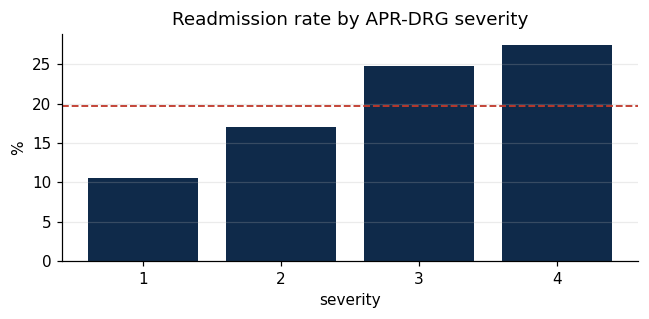


admissions with >=1 procedure: 68.2%
procedures per admission (when present): median 2, max 41

arrived via ED: 57.9%
ED hours: median 6.1, p90 12.5
readmission rate  via ED 20.79%  |  not via ED 18.11%


7100

In [8]:
COH = set(coh.hadm_id)

if has("drgcodes"):
    drg = pd.read_csv(tbl("drgcodes"), usecols=["hadm_id","drg_type","drg_severity","drg_mortality"])
    apr = drg[drg.hadm_id.isin(COH) & drg.drg_type.eq("APR")]
    apr = apr.groupby("hadm_id")[["drg_severity","drg_mortality"]].max()
    print(f"APR-DRG severity coverage : {pct(apr.index.nunique(), len(COH))} of cohort")
    if len(apr):
        tmp = coh.merge(apr, on="hadm_id", how="left")
        g = tmp.groupby("drg_severity").readmit_30d.agg(["size","mean"])
        g = g[g["size"] >= 50]
        if not g.empty:
            print("\nreadmission rate by APR-DRG severity (1=minor .. 4=extreme):")
            print(g.assign(mean=(g["mean"]*100).round(1)).to_string())
            fig, ax = plt.subplots(figsize=(6,3))
            ax.bar(g.index.astype(int).astype(str), g["mean"]*100, color=NAVY)
            ax.axhline(coh.readmit_30d.mean()*100, color=RED, ls="--", lw=1.2)
            ax.set(title="Readmission rate by APR-DRG severity", xlabel="severity", ylabel="%")
            ax.grid(axis="x", visible=False); plt.tight_layout(); plt.show()

if has("procedures_icd"):
    proc = pd.read_csv(tbl("procedures_icd"), usecols=["hadm_id","icd_code"])
    proc = proc[proc.hadm_id.isin(COH)].groupby("hadm_id").size()
    print(f"\nadmissions with >=1 procedure: {pct(len(proc), len(COH))}")
    print(f"procedures per admission (when present): median {proc.median():.0f}, max {proc.max()}")

ed = coh.edregtime.notna()
print(f"\narrived via ED: {ed.mean():.1%}")
if ed.any():
    edh = ((coh.edouttime - coh.edregtime).dt.total_seconds()/3600)
    print(f"ED hours: median {edh.median():.1f}, p90 {edh.quantile(.9):.1f}")
    print(f"readmission rate  via ED {coh[ed].readmit_30d.mean():.2%}"
          f"  |  not via ED {coh[~ed].readmit_30d.mean():.2%}")
gc.collect()

## 1.7 Medications — streamed from `prescriptions.csv` (3.5 GB)

First streamed table. Each chunk is filtered to the cohort and reduced to per-admission
aggregates before the raw rows are discarded.

    chunk   8 |   66.7s | 232,134 admissions
  [cached] meds
  medication aggregates            rows=     294,565  cols=  8  mem=     8.1 MB

share of admissions with each drug class:
anticoagulant    76.1
opioid           64.3
insulin          33.2
diuretic         31.1
antipsychotic    11.7


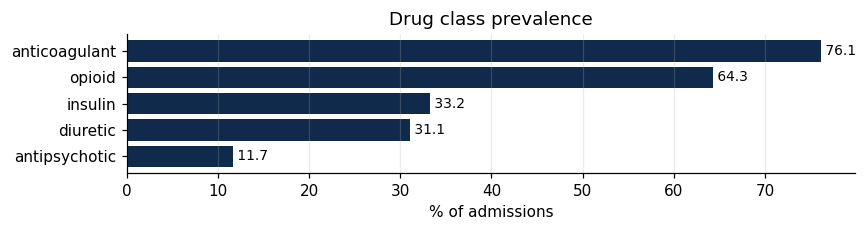


readmission rate by drug class exposure:
  insulin        exposed 23.15%   not exposed 17.95%   diff +5.2 pp
  anticoagulant  exposed 21.45%   not exposed 14.00%   diff +7.5 pp
  opioid         exposed 20.19%   not exposed 18.74%   diff +1.5 pp
  diuretic       exposed 23.10%   not exposed 18.13%   diff +5.0 pp
  antipsychotic  exposed 23.24%   not exposed 19.20%   diff +4.0 pp


In [9]:
DRUG_CLASSES = {
    "insulin":       r"insulin",
    "anticoagulant": r"warfarin|heparin|apixaban|rivaroxaban|enoxaparin|dabigatran",
    "opioid":        r"morphine|oxycodone|hydromorphone|fentanyl|hydrocodone|tramadol",
    "diuretic":      r"furosemide|bumetanide|torsemide|spironolactone|hydrochlorothiazide",
    "antipsychotic": r"haloperidol|quetiapine|olanzapine|risperidone",
}

meds = load_cache("meds")
if meds is None and has("prescriptions"):
    parts, t0 = [], time.time()
    for i, ch in enumerate(pd.read_csv(tbl("prescriptions"), usecols=["hadm_id","drug"],
                                       chunksize=CHUNK_ROWS, dtype={"drug":"string"}), 1):
        ch = ch[ch.hadm_id.isin(COH)]
        if not ch.empty:
            low = ch.drug.str.lower()
            agg = ch.groupby("hadm_id").agg(n_orders=("drug","size"), n_distinct=("drug","nunique"))
            for name, pat in DRUG_CLASSES.items():
                agg[name] = ch.assign(f=low.str.contains(pat, na=False, regex=True)) \
                              .groupby("hadm_id").f.max().astype("int8")
            parts.append(agg.reset_index())
        if i % COMPACT_EVERY == 0 and parts:
            parts = [pd.concat(parts, ignore_index=True).groupby("hadm_id", as_index=False).max()]
            print(f"    chunk {i:>3} | {time.time()-t0:6.1f}s | {len(parts[0]):,} admissions")
        del ch; gc.collect()
    if parts:
        meds = (pd.concat(parts, ignore_index=True).groupby("hadm_id", as_index=False)
                  .agg({"n_orders":"sum","n_distinct":"max", **{k:"max" for k in DRUG_CLASSES}}))
    else:
        print("  WARNING: no prescription rows matched the cohort")
        meds = pd.DataFrame({"hadm_id": pd.Series(dtype="int64")})
    save_cache(meds, "meds")

if meds is not None and len(meds):
    report("medication aggregates", meds)
    prev = meds[[c for c in DRUG_CLASSES if c in meds.columns]].mean().sort_values(ascending=False)
    print("\nshare of admissions with each drug class:")
    print((prev*100).round(1).to_string())
    barh(prev*100, "Drug class prevalence", "% of admissions", fmt="{:.1f}")

    m = coh.merge(meds, on="hadm_id", how="left")
    print("\nreadmission rate by drug class exposure:")
    for c in DRUG_CLASSES:
        if c in m.columns and m[c].notna().any():
            a = m.loc[m[c] == 1, "readmit_30d"].mean(); b = m.loc[m[c] == 0, "readmit_30d"].mean()
            print(f"  {c:<14} exposed {a:.2%}   not exposed {b:.2%}   diff {(a-b)*100:+.1f} pp")

## 1.8 Labs — streamed from `labevents.csv` (18.4 GB)

The largest table by an order of magnitude. Target `itemid`s are resolved first from the 64 KB
dictionary, so the big scan filters on a small integer set rather than matching strings.
Expect roughly 15-35 minutes on the full file; the result is cached.

In [10]:
LAB_PATTERNS = {
    "hba1c": r"hemoglobin a1c|hba1c", "glucose": r"^glucose$", "creatinine": r"^creatinine$",
    "bun": r"urea nitrogen", "sodium": r"^sodium$", "potassium": r"^potassium$",
    "hemoglobin": r"^hemoglobin$", "wbc": r"white blood cells", "platelets": r"platelet count",
    "albumin": r"^albumin$", "bicarbonate": r"^bicarbonate$", "inr": r"^inr\(pt\)$",
}

item_map = {}
if has("d_labitems"):
    dl = pd.read_csv(tbl("d_labitems")); dl["l"] = dl.label.astype(str).str.lower()
    for name, pat in LAB_PATTERNS.items():
        m = dl[dl.l.str.contains(pat, regex=True, na=False)]
        if "fluid" in m.columns:
            blood = m[m.fluid.eq("Blood")]
            m = blood if len(blood) else m
        for iid in m.itemid.tolist():
            item_map[int(iid)] = name
        print(f"  {name:<12} -> {len(m):>2} itemid(s)")
    print(f"\nresolved {len(item_map)} itemids across {len(LAB_PATTERNS)} concepts")
    if "hba1c" not in set(item_map.values()):
        print("  NOTE: HbA1c not resolved in this extract")

  hba1c        ->  1 itemid(s)
  glucose      ->  3 itemid(s)
  creatinine   ->  2 itemid(s)
  bun          ->  2 itemid(s)
  sodium       ->  2 itemid(s)
  potassium    ->  2 itemid(s)
  hemoglobin   ->  3 itemid(s)
  wbc          ->  3 itemid(s)
  platelets    ->  2 itemid(s)
  albumin      ->  2 itemid(s)
  bicarbonate  ->  1 itemid(s)
  inr          ->  2 itemid(s)

resolved 25 itemids across 12 concepts


    chunk   8 |   16.0M rows |   24.6s | kept 261,527
    chunk  16 |   32.0M rows |   49.7s | kept 524,793
    chunk  24 |   48.0M rows |   74.7s | kept 788,251
    chunk  32 |   64.0M rows |  107.0s | kept 1,046,096
    chunk  40 |   80.0M rows |  135.4s | kept 1,310,407
    chunk  48 |   96.0M rows |  162.9s | kept 1,573,197
    chunk  56 |  112.0M rows |  188.9s | kept 1,835,661
    chunk  64 |  128.0M rows |  215.1s | kept 2,101,248
    chunk  72 |  144.0M rows |  241.6s | kept 2,363,840
    chunk  80 |  158.4M rows |  265.5s | kept 2,596,805
  [cached] labs

lab coverage (% of cohort admissions with >=1 result):
lab
platelets      89.1
hemoglobin     89.0
wbc            88.8
creatinine     86.1
bun            85.0
potassium      84.9
sodium         84.5
glucose        84.3
bicarbonate    84.2
inr            58.3
albumin        31.4
hba1c           9.3


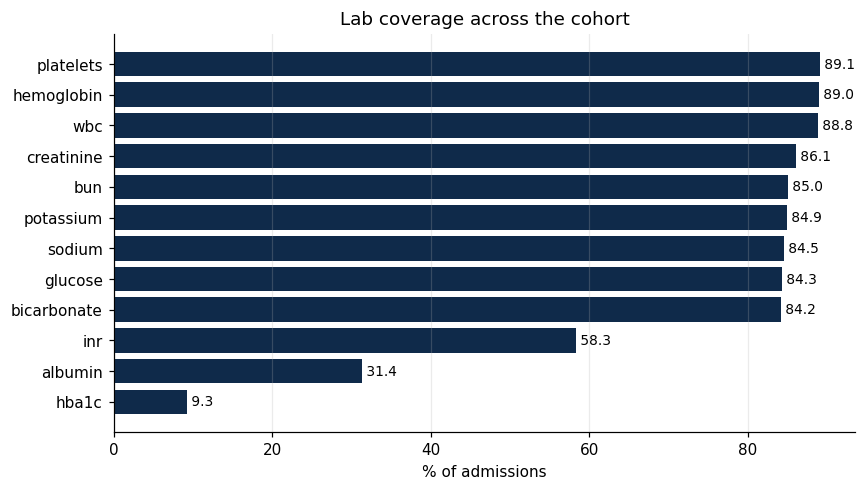


value distribution per lab:
                count    mean     50%     min       max
lab                                                    
albumin       93095.0    3.40    3.40    0.80      6.40
bicarbonate  249929.0   25.67   25.62    9.25     49.50
bun          252376.0   20.41   16.00    1.00    209.06
creatinine   255533.0    1.24    0.90    0.00     29.80
glucose      250288.0  123.56  112.82   23.00  85189.33
hba1c         27629.0    6.63    5.90    3.50     22.00
hemoglobin   264153.0   10.99   10.93    3.40     23.22
inr          173130.0    1.37    1.20    0.45     14.18
platelets    264413.0  234.47  219.10    5.00   2096.89
potassium    251975.0    4.10    4.07    2.30     10.00
sodium       250821.0  138.47  138.75  114.50    167.88
wbc          263463.0    8.91    8.22    0.10    511.02


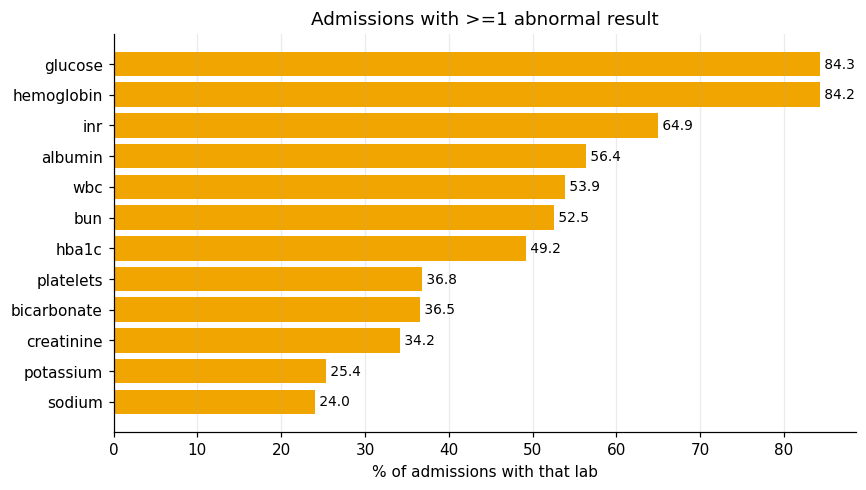

In [11]:
labs = load_cache("labs")
if labs is None and item_map and has("labevents"):
    TARGET = set(item_map); parts, seen, t0 = [], 0, time.time()
    for i, ch in enumerate(pd.read_csv(tbl("labevents"),
            usecols=["hadm_id","itemid","valuenum","flag"], chunksize=CHUNK_ROWS), 1):
        seen += len(ch)
        ch = ch[ch.itemid.isin(TARGET) & ch.hadm_id.isin(COH) & ch.valuenum.notna()]
        if not ch.empty:
            ch["lab"] = ch.itemid.map(item_map)
            ch["abn"] = ch.flag.eq("abnormal").astype("int8")
            parts.append(ch.groupby(["hadm_id","lab"]).agg(
                v=("valuenum","mean"), n=("valuenum","size"), n_abn=("abn","sum")).reset_index())
        if i % COMPACT_EVERY == 0 and parts:
            parts = [pd.concat(parts, ignore_index=True)
                       .groupby(["hadm_id","lab"], as_index=False)
                       .agg(v=("v","mean"), n=("n","sum"), n_abn=("n_abn","sum"))]
            print(f"    chunk {i:>3} | {seen/1e6:6.1f}M rows | {time.time()-t0:6.1f}s "
                  f"| kept {len(parts[0]):,}")
        del ch; gc.collect()
    labs = (pd.concat(parts, ignore_index=True) if parts
            else pd.DataFrame({"hadm_id": pd.Series(dtype="int64"),
                               "lab": pd.Series(dtype="object")}))
    if parts:
        labs = labs.groupby(["hadm_id","lab"], as_index=False).agg(
            v=("v","mean"), n=("n","sum"), n_abn=("n_abn","sum"))
    save_cache(labs, "labs")

if labs is not None and len(labs):
    cov = (labs.groupby("lab").hadm_id.nunique()/max(len(COH),1)*100).sort_values(ascending=False)
    print("\nlab coverage (% of cohort admissions with >=1 result):")
    print(cov.round(1).to_string())
    barh(cov, "Lab coverage across the cohort", "% of admissions", fmt="{:.1f}")

    print("\nvalue distribution per lab:")
    print(labs.groupby("lab").v.describe()[["count","mean","50%","min","max"]].round(2).to_string())

    ab = (labs.assign(any_abn=labs.n_abn > 0).groupby("lab").any_abn.mean()*100).sort_values(ascending=False)
    barh(ab, "Admissions with >=1 abnormal result", "% of admissions with that lab",
         color=AMBER, fmt="{:.1f}")

## 1.9 Missingness across the assembled feature set

missing % by column:
days_since_prev       42.4
edregtime             42.1
marital_status         2.7
insurance              1.2
diuretic               0.7
opioid                 0.7
insulin                0.7
n_distinct             0.7
n_orders               0.7
anticoagulant          0.7
antipsychotic          0.7
discharge_location     0.2
gender                 0.0
anchor_age             0.0
n_prior_adm            0.0
los_days               0.0
race                   0.0
admission_type         0.0


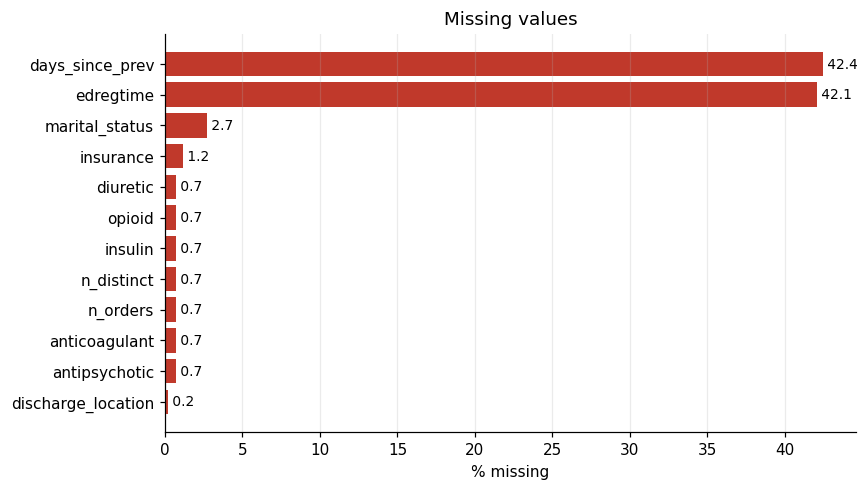


Note: days_since_prev is missing by construction for a patient's FIRST admission,
so its missing rate is roughly the share of patients with only one stay.


In [12]:
prof = coh[["anchor_age","gender","race","marital_status","insurance","admission_type",
            "discharge_location","los_days","n_prior_adm","days_since_prev","edregtime"]].copy()
if meds is not None and len(meds):
    prof = prof.join(coh[["hadm_id"]].merge(meds, on="hadm_id", how="left")
                        .drop(columns=["hadm_id"]))
miss = (prof.isna().mean()*100).sort_values(ascending=False)
print("missing % by column:"); print(miss.round(1).to_string())
barh(miss[miss > 0], "Missing values", "% missing", color=RED, fmt="{:.1f}")
print("\nNote: days_since_prev is missing by construction for a patient's FIRST admission,")
print("so its missing rate is roughly the share of patients with only one stay.")

---
# Part 2 · Post-discharge data

`omr` is the only outpatient table in the `hosp` module. Everything Phase 2 could possibly use
comes from here, so this section establishes what it contains and — the decisive question —
whether observations arrive on anything resembling a **weekly** cadence.

  omr (raw)                        rows=   7,753,027  cols=  4  mem=   971.4 MB

columns: ['subject_id', 'chartdate', 'result_name', 'result_value']
distinct patients: 193,501
date span        : 2105-01-19 -> 2215-04-14

measurement types available:
result_name
Blood Pressure                      2827801
Weight (Lbs)                        2145353
BMI (kg/m2)                         1901496
Height (Inches)                      814964
BMI                                   29021
Weight                                15108
Blood Pressure Sitting                 5757
Blood Pressure Standing (1 min)        4704
Blood Pressure Lying                   4359
Height                                 2365
Blood Pressure Standing (3 mins)       1255
Blood Pressure Standing                 565
eGFR                                    279


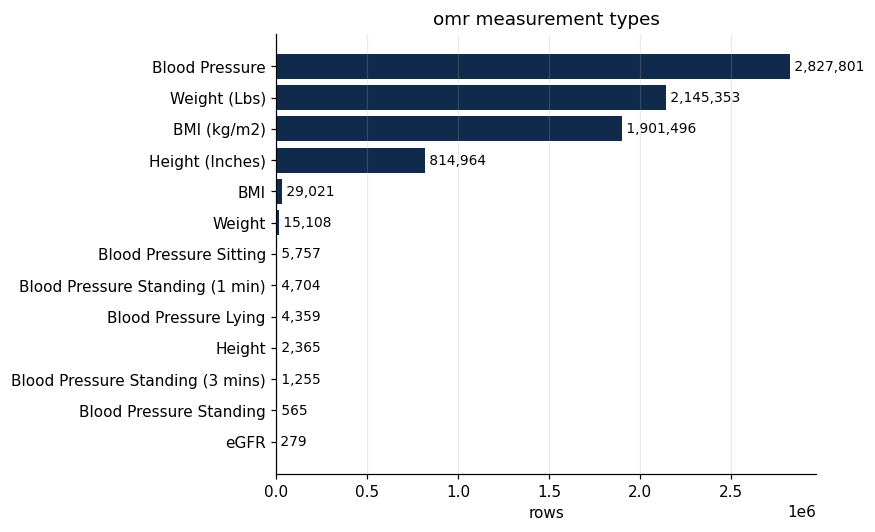


rows per patient across their ENTIRE record: median 12, mean 40.1, max 2442
This is a whole-lifetime figure, not a per-window one - keep that in mind below.


In [13]:
if not has("omr"):
    raise FileNotFoundError("omr.csv not present - Phase 2 cannot be profiled")

omr = pd.read_csv(tbl("omr"), usecols=["subject_id","chartdate","result_name","result_value"],
                  parse_dates=["chartdate"])
report("omr (raw)", omr)
print("\ncolumns:", list(omr.columns))
print(f"distinct patients: {omr.subject_id.nunique():,}")
print(f"date span        : {omr.chartdate.min().date()} -> {omr.chartdate.max().date()}")

print("\nmeasurement types available:")
vc = omr.result_name.value_counts()
print(vc.to_string())
barh(vc, "omr measurement types", "rows", fmt="{:,.0f}")

per = omr.groupby("subject_id").size()
print(f"\nrows per patient across their ENTIRE record: "
      f"median {per.median():.0f}, mean {per.mean():.1f}, max {per.max()}")
print("This is a whole-lifetime figure, not a per-window one - keep that in mind below.")

## 2.1 Parsing the measurements

implausible values dropped: 6,542
  tidy observations                rows=  10,589,231  cols=  4  mem=   865.3 MB

               count   mean    50%    min    max
measure                                         
bmi        1929401.0   29.1   28.0   10.0   90.0
dbp        2842420.0   74.0   74.0   30.0  160.0
height_cm   814262.0  166.4  165.7  120.0  218.4
sbp        2843678.0  127.6  126.0   60.0  250.0
weight_kg  2159470.0   80.9   77.6   25.1  350.0


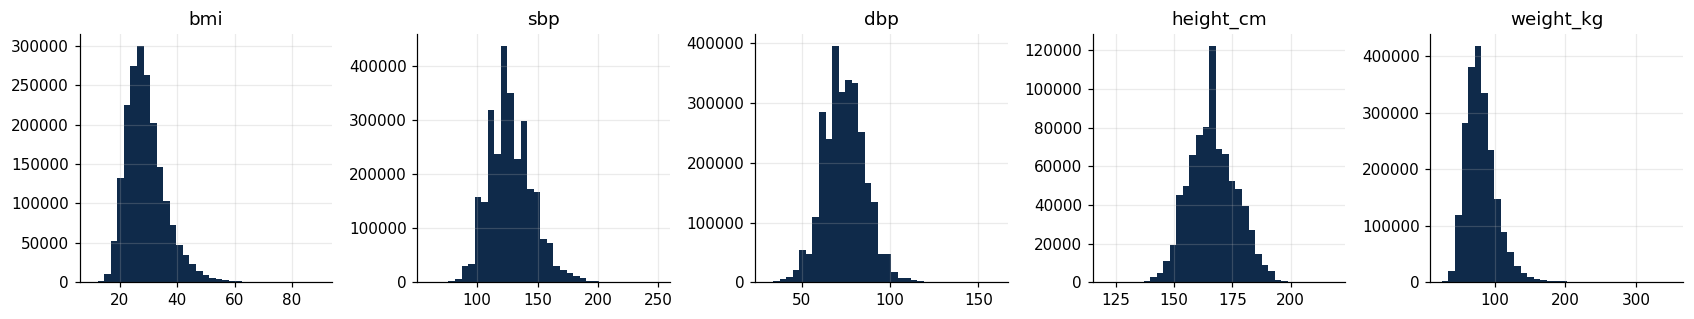

In [14]:
def parse_bp(s):
    m = re.match(r"\s*(\d{2,3})\s*/\s*(\d{2,3})", str(s))
    return (float(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)

recs = []
for name, grp in omr.groupby("result_name"):
    n = str(name).lower()
    if "blood pressure" in n:
        sd = grp.result_value.map(parse_bp)
        recs.append(grp.assign(measure="sbp", value=[a for a,_ in sd])[["subject_id","chartdate","measure","value"]])
        recs.append(grp.assign(measure="dbp", value=[b for _,b in sd])[["subject_id","chartdate","measure","value"]])
    elif "weight" in n:
        v = pd.to_numeric(grp.result_value, errors="coerce")
        if "lbs" in n: v = v*0.453592
        recs.append(grp.assign(measure="weight_kg", value=v)[["subject_id","chartdate","measure","value"]])
    elif "bmi" in n:
        recs.append(grp.assign(measure="bmi", value=pd.to_numeric(grp.result_value, errors="coerce"))
                       [["subject_id","chartdate","measure","value"]])
    elif "height" in n:
        v = pd.to_numeric(grp.result_value, errors="coerce")
        if "inches" in n: v = v*2.54
        recs.append(grp.assign(measure="height_cm", value=v)[["subject_id","chartdate","measure","value"]])

obs = pd.concat(recs, ignore_index=True).dropna(subset=["value"])
BOUNDS = {"sbp":(60,260),"dbp":(30,160),"weight_kg":(25,350),"bmi":(10,90),"height_cm":(120,220)}
before = len(obs)
for m,(lo,hi) in BOUNDS.items():
    obs = obs[~(obs.measure.eq(m) & ~obs.value.between(lo,hi))]
print(f"implausible values dropped: {before-len(obs):,}")
report("tidy observations", obs)
print()
print(obs.groupby("measure").value.describe()[["count","mean","50%","min","max"]].round(1).to_string())

meas = obs.measure.unique()
fig, ax = plt.subplots(1, len(meas), figsize=(3.1*len(meas), 3))
ax = np.atleast_1d(ax)
for a, m in zip(ax, meas):
    a.hist(obs.loc[obs.measure.eq(m), "value"], bins=35, color=NAVY)
    a.set(title=m, xlabel="")
plt.tight_layout(); plt.show()

## 2.2 The decisive question — is there a weekly cadence?

Joins every eligible discharge to that patient's later observations and measures how long the
first one takes to arrive, then how many distinct **weeks** are covered inside each window.

discharges with >=1 later observation : 212,451 / 296,760 (71.6%)

days until FIRST post-discharge observation
  p10  :        3 days
  p25  :        8 days
  p50  :       22 days
  p75  :       96 days
  p90  :      552 days


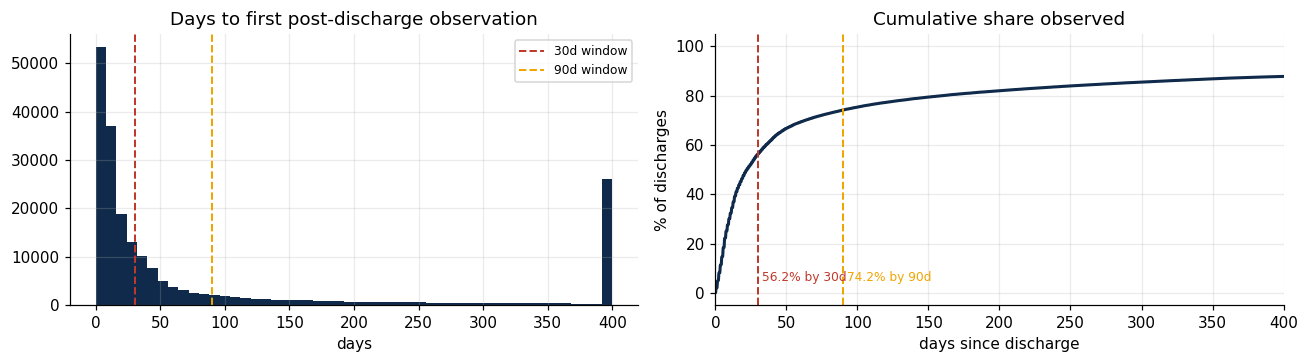


distinct WEEKS containing >=1 observation, per discharge
  within  30d ( 4 possible) : median 0 | mean 0.67 | >=2 weeks 16.9%
  within  90d (12 possible) : median 1 | mean 1.58 | >=2 weeks 34.8%
  within 180d (25 possible) : median 1 | mean 2.58 | >=2 weeks 43.3%


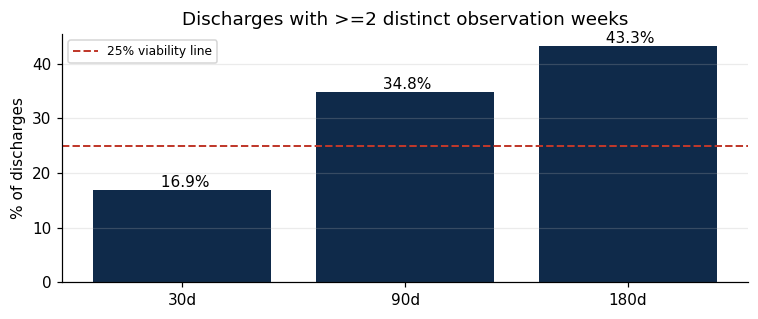


VERDICT: weekly re-scoring is NOT supportable from MIMIC-IV.
  omr is opportunistic clinic measurement, not scheduled monitoring.
  Phase 2 must use irregular-interval features (last observation + an
  explicit staleness term), or source the cadence elsewhere.


In [15]:
WINDOWS = (30, 90, 180)

disch = coh[["subject_id","hadm_id","dischtime","readmit_30d"]]
j = disch.merge(obs, on="subject_id", how="inner")
j = j[j.chartdate > j.dischtime].copy()
j["days_after"] = (j.chartdate - j.dischtime).dt.total_seconds()/86400

if j.empty:
    print("No post-discharge observations at all - Phase 2 is not supportable on this extract.")
else:
    first = j.groupby("hadm_id").days_after.min()
    print(f"discharges with >=1 later observation : {len(first):,} / {len(disch):,} "
          f"({pct(len(first), len(disch))})\n")
    print("days until FIRST post-discharge observation")
    qs = [10,25,50,75,90]
    for q in qs: print(f"  p{q:<3} : {np.percentile(first,q):8.0f} days")

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
    ax[0].hist(first.clip(0, 400), bins=50, color=NAVY)
    for d,c in [(30,RED),(90,AMBER)]:
        ax[0].axvline(d, color=c, ls="--", lw=1.3, label=f"{d}d window")
    ax[0].set(title="Days to first post-discharge observation", xlabel="days"); ax[0].legend(fontsize=8)
    xs = np.sort(first.values); ys = np.arange(1,len(xs)+1)/len(xs)*100
    ax[1].plot(xs, ys, color=NAVY, lw=2)
    for d,c in [(30,RED),(90,AMBER)]:
        ax[1].axvline(d, color=c, ls="--", lw=1.3)
        ax[1].text(d, 5, f" {(first<=d).mean()*100:.1f}% by {d}d", fontsize=8, color=c)
    ax[1].set(title="Cumulative share observed", xlabel="days since discharge",
              ylabel="% of discharges", xlim=(0,400))
    plt.tight_layout(); plt.show()

    print("\ndistinct WEEKS containing >=1 observation, per discharge")
    summary = {}
    for w in WINDOWS:
        win = j[j.days_after <= w].copy()
        if win.empty:
            print(f"  within {w:>3}d : none"); summary[w]=0.0; continue
        win["week"] = (win.days_after//7).astype(int)
        weeks = win.groupby("hadm_id").week.nunique().reindex(disch.hadm_id.unique()).fillna(0)
        summary[w] = (weeks>=2).mean()
        print(f"  within {w:>3}d ({w//7:>2} possible) : median {weeks.median():.0f} | "
              f"mean {weeks.mean():.2f} | >=2 weeks {summary[w]:.1%}")

    fig, ax = plt.subplots(figsize=(7,3))
    ax.bar([f"{w}d" for w in WINDOWS], [summary[w]*100 for w in WINDOWS], color=NAVY)
    ax.axhline(25, color=RED, ls="--", lw=1.3, label="25% viability line")
    for i,w in enumerate(WINDOWS): ax.text(i, summary[w]*100, f" {summary[w]*100:.1f}%", ha="center", va="bottom")
    ax.set(title="Discharges with >=2 distinct observation weeks", ylabel="% of discharges")
    ax.grid(axis="x", visible=False); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print("\n" + "="*70)
    if summary.get(30,0) >= .25:
        print("VERDICT: enough density to attempt weekly binning inside 30 days.")
    else:
        print("VERDICT: weekly re-scoring is NOT supportable from MIMIC-IV.")
        print("  omr is opportunistic clinic measurement, not scheduled monitoring.")
        print("  Phase 2 must use irregular-interval features (last observation + an")
        print("  explicit staleness term), or source the cadence elsewhere.")
    print("="*70)

## 2.3 Coverage and what the observed subgroup looks like

Patients WITH post-discharge observations differ from those without,
so any Phase 2 model applies to a self-selected subgroup:

               with_obs  without_obs
n             212451.00    84309.000
readmit_rate       0.22        0.138
mean_age          57.40       58.125
mean_los           5.76        6.034

observations per discharge (when any): median 28, p90 229, max 3062


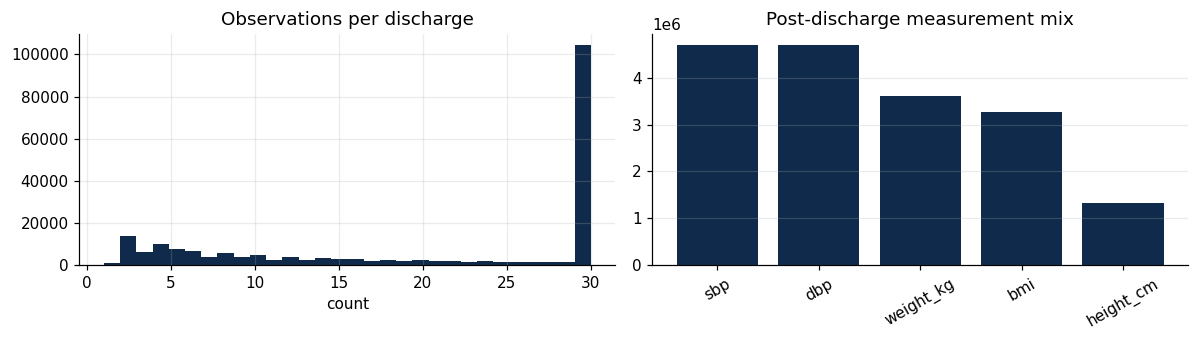

In [16]:
if not j.empty:
    has_obs = disch.hadm_id.isin(set(j.hadm_id))
    print("Patients WITH post-discharge observations differ from those without,")
    print("so any Phase 2 model applies to a self-selected subgroup:\n")
    cmp = pd.DataFrame({
        "with_obs": [has_obs.sum(), coh.loc[has_obs.values,"readmit_30d"].mean(),
                     coh.loc[has_obs.values,"anchor_age"].mean(),
                     coh.loc[has_obs.values,"los_days"].mean()],
        "without_obs": [(~has_obs).sum(), coh.loc[~has_obs.values,"readmit_30d"].mean(),
                        coh.loc[~has_obs.values,"anchor_age"].mean(),
                        coh.loc[~has_obs.values,"los_days"].mean()],
    }, index=["n","readmit_rate","mean_age","mean_los"])
    print(cmp.round(3).to_string())

    n_obs = j.groupby("hadm_id").size()
    print(f"\nobservations per discharge (when any): median {n_obs.median():.0f}, "
          f"p90 {n_obs.quantile(.9):.0f}, max {n_obs.max()}")

    fig, ax = plt.subplots(1, 2, figsize=(11,3.2))
    ax[0].hist(n_obs.clip(0,30), bins=30, color=NAVY)
    ax[0].set(title="Observations per discharge", xlabel="count")
    mc = j.measure.value_counts()
    ax[1].bar(mc.index.astype(str), mc.values, color=NAVY)
    ax[1].set(title="Post-discharge measurement mix"); ax[1].tick_params(axis="x", rotation=30)
    ax[1].grid(axis="x", visible=False)
    plt.tight_layout(); plt.show()

---
## Summary

Fill in against your own run; the shape below is what the full extract produced.

**Phase 1 — discharge-time data is sufficient.**
The 30-day unplanned readmission label constructs cleanly, the positive rate is in a plausible
range, and the features with the widest rate spreads (discharge destination, prior admissions,
APR-DRG severity, length of stay) are exactly the ones clinical literature expects. Watch the
ICD-9/ICD-10 split — any comorbidity mapping has to cover both.

**Phase 2 — post-discharge data does not support a weekly cadence.**
`omr` holds four measurement types, recorded when a patient happens to attend clinic. The
percentage of discharges with two or more distinct observation weeks inside 30 days is the number
that matters; if it is far below 25%, weekly re-scoring is not defensible on this data regardless
of sample size, and the coverage comparison in 2.3 shows the observed subgroup is not
representative either.